# Modelling v2

## Imports and constants

In [58]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.features import rasterize
import geopandas as gpd

PATCH_SIZE = 32
TARGET = "logratio"
ENDPOINT_THRESHOLD = 0.0
FORCE_REBUILD_PATCH_CACHE = True

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = Path(".")
DRIVE_ROOT = Path("/content/drive/MyDrive/balkans_master_data/fixed-dates-patch")
PATCH_CACHE_DIR = PROJECT_ROOT / f"data/patches_v5_{PATCH_SIZE}x{PATCH_SIZE}_mega"
PATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRIES = [
    "Albania",
    "Bosnia_and_Herzegovina",
    "Kosovo",
    "Montenegro",
    "North_Macedonia",
    "Serbia",
]

COUNTRY_GADM_CODES = {
    "Albania": "ALB",
    "Bosnia_and_Herzegovina": "BIH",
    "Kosovo": "XKO",
    "Montenegro": "MNE",
    "North_Macedonia": "MKD",
    "Serbia": "SRB",
}

MEGA_TIFF_CANDIDATES = [
    DRIVE_ROOT / "balkans_all_v4.tif",
    DRIVE_ROOT / "balkans_al_v4.tif",
    PROJECT_ROOT / "data/gee/v4/balkans_all_v4.tif",
    PROJECT_ROOT / "balkans_all_v4.tif",
    Path("/content/data/gee/v4/balkans_all_v4.tif"),
    Path("/content/balkans_all_v4.tif"),
]

BOUNDARY_DIR_CANDIDATES = [
    DRIVE_ROOT / "gadm",
    PROJECT_ROOT / "data/gadm",
    Path("/content/data/gadm"),
    Path("/content/gadm"),
]

MEGA_CHANNEL_NAMES = [
    "VIIRS 2013",
    "VIIRS 2014",
    "VIIRS 2015",
    "VIIRS 2016",
    "Built-up fraction",
    "Population (log1p after patch build)",
    "Elevation",
    "Slope",
    "Infra proximity (log1p after patch build)",
    "SMOD code",
    "VIIRS 2017",
]

INPUT_CHANNELS = [0, 4, 5, 6, 7, 8, 9]
CHANNEL_NAMES = [MEGA_CHANNEL_NAMES[i] for i in INPUT_CHANNELS]

def resolve_existing_path(candidates, label):
    for path in candidates:
        if path.exists():
            return path
    tried = [str(p) for p in candidates]
    raise FileNotFoundError(f"Could not find {label}. Tried: {tried}")

MEGA_TIFF_PATH = resolve_existing_path(MEGA_TIFF_CANDIDATES, "Balkans mega TIFF")
BOUNDARY_DIR = resolve_existing_path(BOUNDARY_DIR_CANDIDATES, "GADM boundary directory")

missing_gpkg = [
    str(BOUNDARY_DIR / f"gadm41_{COUNTRY_GADM_CODES[country]}.gpkg")
    for country in COUNTRIES
    if not (BOUNDARY_DIR / f"gadm41_{COUNTRY_GADM_CODES[country]}.gpkg").exists()
]
if missing_gpkg:
    raise FileNotFoundError(
        "Missing GADM boundary files needed to rasterize the country masks. "
        f"Missing: {missing_gpkg}"
    )

N_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Drive root:", DRIVE_ROOT)
print("Mega TIFF:", MEGA_TIFF_PATH.resolve())
print("Boundary dir:", BOUNDARY_DIR.resolve())
print("Patch cache:", PATCH_CACHE_DIR.resolve())
print(f"Input channels ({len(INPUT_CHANNELS)}):", CHANNEL_NAMES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Drive root: /content/drive/MyDrive/balkans_master_data/fixed-dates-patch
Mega TIFF: /content/drive/MyDrive/balkans_master_data/fixed-dates-patch/balkans_all_v4.tif
Boundary dir: /content/drive/MyDrive/balkans_master_data/fixed-dates-patch/gadm
Patch cache: /content/data/patches_v5_32x32_mega
Input channels (7): ['VIIRS 2013', 'Built-up fraction', 'Population (log1p after patch build)', 'Elevation', 'Slope', 'Infra proximity (log1p after patch build)', 'SMOD code']


## Load patches

In [59]:
if TARGET != "logratio":
    raise NotImplementedError(
        "The mega-TIFF preprocessing path currently supports TARGET='logratio' only."
    )

# Patch geometry settings
PATCH_STRIDE = 16          # use overlap, matching the old 32x32 setup
MIN_COUNTRY_SHARE = 0.0    # keep every intersecting patch for now


def cache_paths(country: str) -> dict:
    return {
        "patches": PATCH_CACHE_DIR / f"{country}_patches.npy",
        "labels": PATCH_CACHE_DIR / f"{country}_labels_{TARGET}.npy",
        "coords": PATCH_CACHE_DIR / f"{country}_coords.npy",
        "mask": PATCH_CACHE_DIR / f"{country}_valid_mask.npy",
        "share": PATCH_CACHE_DIR / f"{country}_in_country_share.npy",
        "logratio": PATCH_CACHE_DIR / f"{country}_logratio_mean.npy",
    }


def cache_complete() -> bool:
    return all(path.exists() for country in COUNTRIES for path in cache_paths(country).values())


def pad_to_patch_multiple(arr: np.ndarray, patch_size: int, fill_value=0):
    h, w = arr.shape[-2], arr.shape[-1]
    padded_h = int(np.ceil(h / patch_size) * patch_size)
    padded_w = int(np.ceil(w / patch_size) * patch_size)
    pad_h = padded_h - h
    pad_w = padded_w - w
    pad_spec = [(0, 0)] * arr.ndim
    pad_spec[-2] = (0, pad_h)
    pad_spec[-1] = (0, pad_w)
    return np.pad(arr, pad_spec, mode="constant", constant_values=fill_value), padded_h, padded_w


def load_country_boundary(country: str, target_crs):
    gpkg = BOUNDARY_DIR / f"gadm41_{COUNTRY_GADM_CODES[country]}.gpkg"
    gdf = gpd.read_file(gpkg, layer="ADM_ADM_0")
    if target_crs is not None:
        gdf = gdf.to_crs(target_crs)
    gdf["country"] = country
    return gdf


def transform_full_stack(raw_stack: np.ndarray) -> np.ndarray:
    data = raw_stack.astype(np.float32).copy()
    data[0:4] = np.log1p(np.clip(data[0:4], 0, None))
    data[5] = np.log1p(np.clip(data[5], 0, None))
    data[8] = np.log1p(np.clip(data[8], 0, None))
    data[10] = np.log1p(np.clip(data[10], 0, None))
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    return data.astype(np.float32)


def build_patch_cache(force_rebuild: bool = False):
    if cache_complete() and not force_rebuild:
        print("Patch cache already exists; reusing cached mega-TIFF patches.")
        return

    PATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    with rasterio.open(MEGA_TIFF_PATH) as src:
        raw_stack = src.read().astype(np.float32)
        base_transform = src.transform
        base_crs = src.crs
        base_shape = (src.height, src.width)

    transformed_stack = transform_full_stack(raw_stack)

    old_patch_dir = PROJECT_ROOT / f"data/patches_v4_{PATCH_SIZE}x{PATCH_SIZE}"
    old_patch_counts = {}
    if old_patch_dir.exists():
        for country in COUNTRIES:
            old_path = old_patch_dir / f"{country}_patches.npy"
            if old_path.exists():
                old_patch_counts[country] = int(np.load(old_path, mmap_mode="r").shape[0])

    print("Building country-anchored, country-masked patches from the mega TIFF...")
    print("Base raster shape:", raw_stack.shape)
    print("Patch size:", PATCH_SIZE, "| stride:", PATCH_STRIDE)

    for country in COUNTRIES:
        boundary_gdf = load_country_boundary(country, base_crs)
        mask_base = rasterize(
            [(geom, 1) for geom in boundary_gdf.geometry],
            out_shape=base_shape,
            transform=base_transform,
            fill=0,
            all_touched=False,
            dtype="uint8",
        ).astype(bool)

        country_pixels = np.argwhere(mask_base)
        if len(country_pixels) == 0:
            raise ValueError(f"{country}: empty rasterized mask.")

        y_min, x_min = country_pixels.min(axis=0)
        y_max, x_max = country_pixels.max(axis=0)

        stack_crop = transformed_stack[:, y_min:y_max + 1, x_min:x_max + 1]
        mask_crop = mask_base[y_min:y_max + 1, x_min:x_max + 1]

        stack_pad, padded_h, padded_w = pad_to_patch_multiple(stack_crop, PATCH_SIZE, fill_value=0.0)
        mask_pad, _, _ = pad_to_patch_multiple(mask_crop.astype(np.uint8), PATCH_SIZE, fill_value=0)
        mask_pad = mask_pad.astype(bool)

        patches = []
        labels_source = []
        coords = []
        valid_masks = []
        shares = []

        for y_local in range(0, padded_h - PATCH_SIZE + 1, PATCH_STRIDE):
            for x_local in range(0, padded_w - PATCH_SIZE + 1, PATCH_STRIDE):
                patch_mask = mask_pad[y_local:y_local + PATCH_SIZE, x_local:x_local + PATCH_SIZE]
                if not patch_mask.any():
                    continue

                share = float(patch_mask.mean())
                if share < MIN_COUNTRY_SHARE:
                    continue

                vi13_log = stack_pad[0, y_local:y_local + PATCH_SIZE, x_local:x_local + PATCH_SIZE][patch_mask]
                vi17_log = stack_pad[10, y_local:y_local + PATCH_SIZE, x_local:x_local + PATCH_SIZE][patch_mask]
                valid_target = np.isfinite(vi13_log) & np.isfinite(vi17_log)
                if valid_target.sum() == 0:
                    continue

                patch = stack_pad[INPUT_CHANNELS, y_local:y_local + PATCH_SIZE, x_local:x_local + PATCH_SIZE].copy()
                patch[:, ~patch_mask] = 0.0

                y_global = int(y_min + y_local)
                x_global = int(x_min + x_local)

                patches.append(patch.astype(np.float32))
                labels_source.append(float(np.mean(vi17_log[valid_target] - vi13_log[valid_target])))
                coords.append((y_global, x_global))
                valid_masks.append(patch_mask.astype(np.uint8))
                shares.append(share)

        if not patches:
            raise ValueError(f"{country}: no retained patches after country-specific tiling.")

        patches = np.stack(patches).astype(np.float32)
        labels_source = np.asarray(labels_source, dtype=np.float32)
        coords = np.asarray(coords, dtype=np.int32)
        valid_masks = np.stack(valid_masks).astype(np.uint8)
        shares = np.asarray(shares, dtype=np.float32)

        q1, q2 = np.quantile(labels_source, [1 / 3, 2 / 3])
        labels = np.digitize(labels_source, bins=[q1, q2], right=True).astype(np.int64)

        paths = cache_paths(country)
        np.save(paths["patches"], patches)
        np.save(paths["labels"], labels)
        np.save(paths["coords"], coords)
        np.save(paths["mask"], valid_masks)
        np.save(paths["share"], shares)
        np.save(paths["logratio"], labels_source)

        bincount = np.bincount(labels, minlength=3)
        msg = (
            f"{country}: {patches.shape} | class counts {bincount} "
            f"| mean in-country share {shares.mean():.3f}"
        )
        if country in old_patch_counts:
            delta = patches.shape[0] - old_patch_counts[country]
            msg += f" | old v4 count {old_patch_counts[country]} ({delta:+d})"
        print(msg)


build_patch_cache(force_rebuild=FORCE_REBUILD_PATCH_CACHE)

all_patches = {}
all_labels = {}
all_patch_coords = {}
all_valid_masks = {}
all_in_country_share = {}
all_logratio_mean = {}

for country in COUNTRIES:
    paths = cache_paths(country)
    patches = np.load(paths["patches"]).astype(np.float32)
    labels = np.load(paths["labels"]).astype(np.int64)
    coords = np.load(paths["coords"]).astype(np.int32)
    valid_masks = np.load(paths["mask"]).astype(bool)
    shares = np.load(paths["share"]).astype(np.float32)
    logratio_mean = np.load(paths["logratio"]).astype(np.float32)

    if patches.shape[1:] != (len(INPUT_CHANNELS), PATCH_SIZE, PATCH_SIZE):
        raise ValueError(
            f"{country}: expected cached patch shape (n, {len(INPUT_CHANNELS)}, {PATCH_SIZE}, {PATCH_SIZE}), "
            f"got {patches.shape}"
        )
    if not (len(patches) == len(labels) == len(coords) == len(valid_masks) == len(shares) == len(logratio_mean)):
        raise ValueError(f"{country}: cached arrays have inconsistent lengths.")

    all_patches[country] = patches
    all_labels[country] = labels
    all_patch_coords[country] = coords
    all_valid_masks[country] = valid_masks
    all_in_country_share[country] = shares
    all_logratio_mean[country] = logratio_mean

    print(
        f"{country}: {patches.shape} | class counts {np.bincount(labels, minlength=3)} "
        f"| coord windows {coords.shape[0]}"
    )

Building country-anchored, country-masked patches from the mega TIFF...
Base raster shape: (11, 1458, 1627)
Patch size: 32 | stride: 16
Albania: (740, 7, 32, 32) | class counts [247 246 247] | mean in-country share 0.803
Bosnia_and_Herzegovina: (1314, 7, 32, 32) | class counts [438 438 438] | mean in-country share 0.844
Kosovo: (311, 7, 32, 32) | class counts [104 103 104] | mean in-country share 0.733
Montenegro: (379, 7, 32, 32) | class counts [127 126 126] | mean in-country share 0.740
North_Macedonia: (615, 7, 32, 32) | class counts [205 205 205] | mean in-country share 0.842
Serbia: (1994, 7, 32, 32) | class counts [665 664 665] | mean in-country share 0.854
Albania: (740, 7, 32, 32) | class counts [247 246 247] | coord windows 740
Bosnia_and_Herzegovina: (1314, 7, 32, 32) | class counts [438 438 438] | coord windows 1314
Kosovo: (311, 7, 32, 32) | class counts [104 103 104] | coord windows 311
Montenegro: (379, 7, 32, 32) | class counts [127 126 126] | coord windows 379
North_Mac

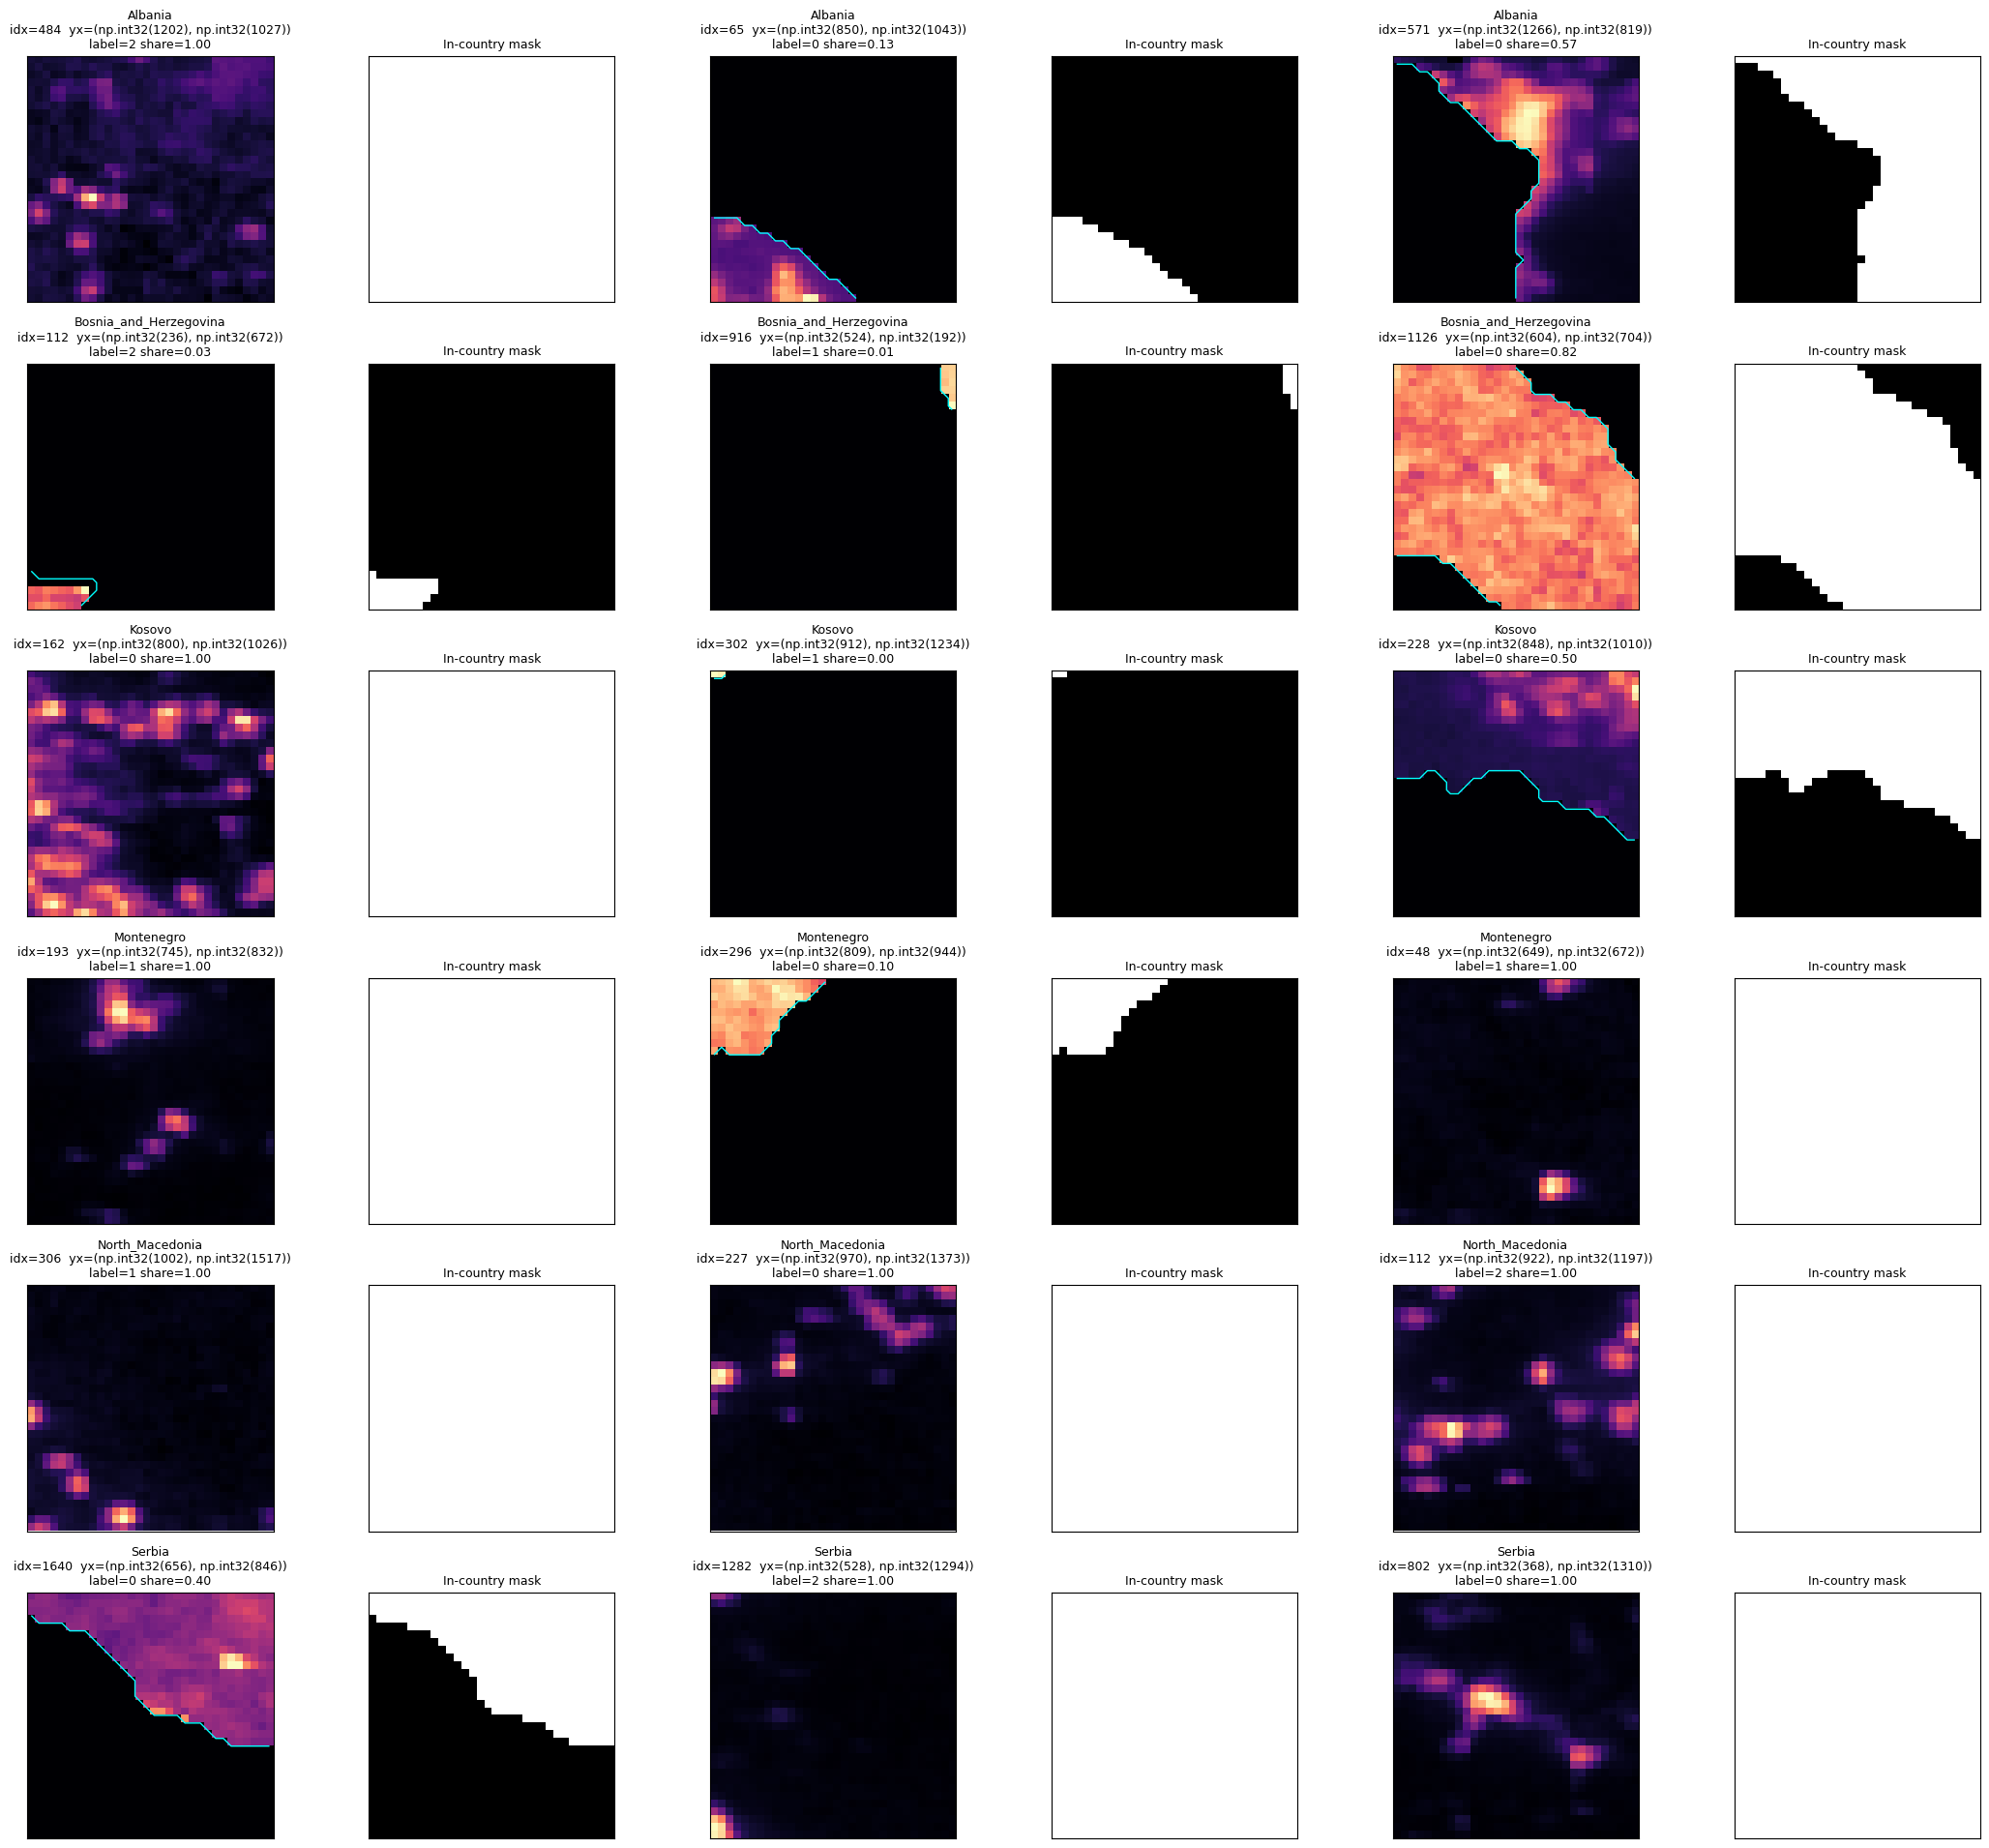

In [60]:
# Quick visual check of cached country-masked patches
# Shows a few random patches per country plus the in-country valid mask.
# Assumes the cache-build cell has already run.

import numpy as np
import matplotlib.pyplot as plt

DISPLAY_CHANNELS = {
    "VIIRS 2013": 0,
    "Built-up": 1,
    "Population": 2,
    "SMOD": 6,
}

rng = np.random.default_rng(42)
n_show = 3

fig, axes = plt.subplots(
    len(COUNTRIES),
    n_show * 2,
    figsize=(3.6 * n_show * 2, 3.2 * len(COUNTRIES)),
)

if len(COUNTRIES) == 1:
    axes = np.array([axes])

for row, country in enumerate(COUNTRIES):
    patches = all_patches[country]
    masks = all_valid_masks[country]
    coords = all_patch_coords[country]
    shares = all_in_country_share[country]
    labels = all_labels[country]

    idxs = rng.choice(len(patches), size=min(n_show, len(patches)), replace=False)

    for j, idx in enumerate(idxs):
        patch = patches[idx]
        mask = masks[idx]
        coord = coords[idx]
        share = shares[idx]
        label = labels[idx]

        # left: VIIRS 2013 patch
        ax = axes[row, 2 * j]
        vi = patch[DISPLAY_CHANNELS["VIIRS 2013"]]
        im = ax.imshow(vi, cmap="magma")
        ax.contour(mask.astype(float), levels=[0.5], colors="cyan", linewidths=1)
        ax.set_title(
            f"{country}\nidx={idx}  yx={tuple(coord)}\nlabel={label} share={share:.2f}",
            fontsize=9
        )
        ax.set_xticks([])
        ax.set_yticks([])

        # right: valid in-country mask
        axm = axes[row, 2 * j + 1]
        axm.imshow(mask, cmap="gray", vmin=0, vmax=1)
        axm.set_title("In-country mask", fontsize=9)
        axm.set_xticks([])
        axm.set_yticks([])

plt.tight_layout()
plt.show()

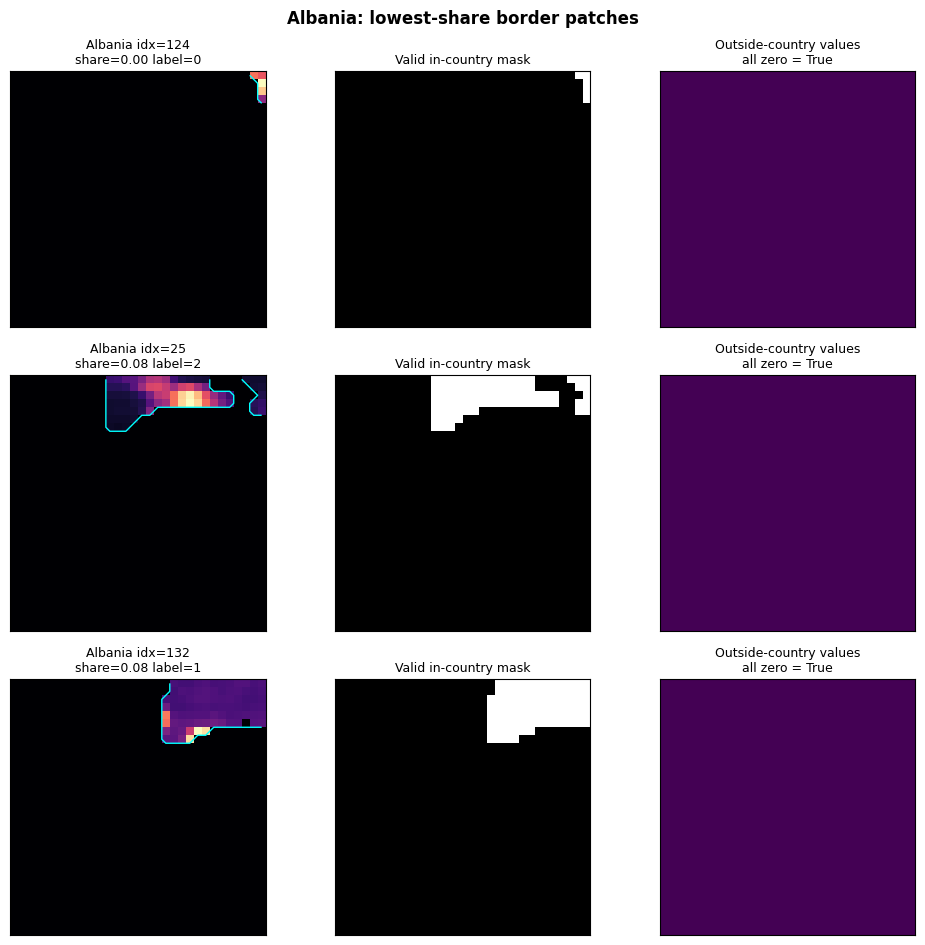

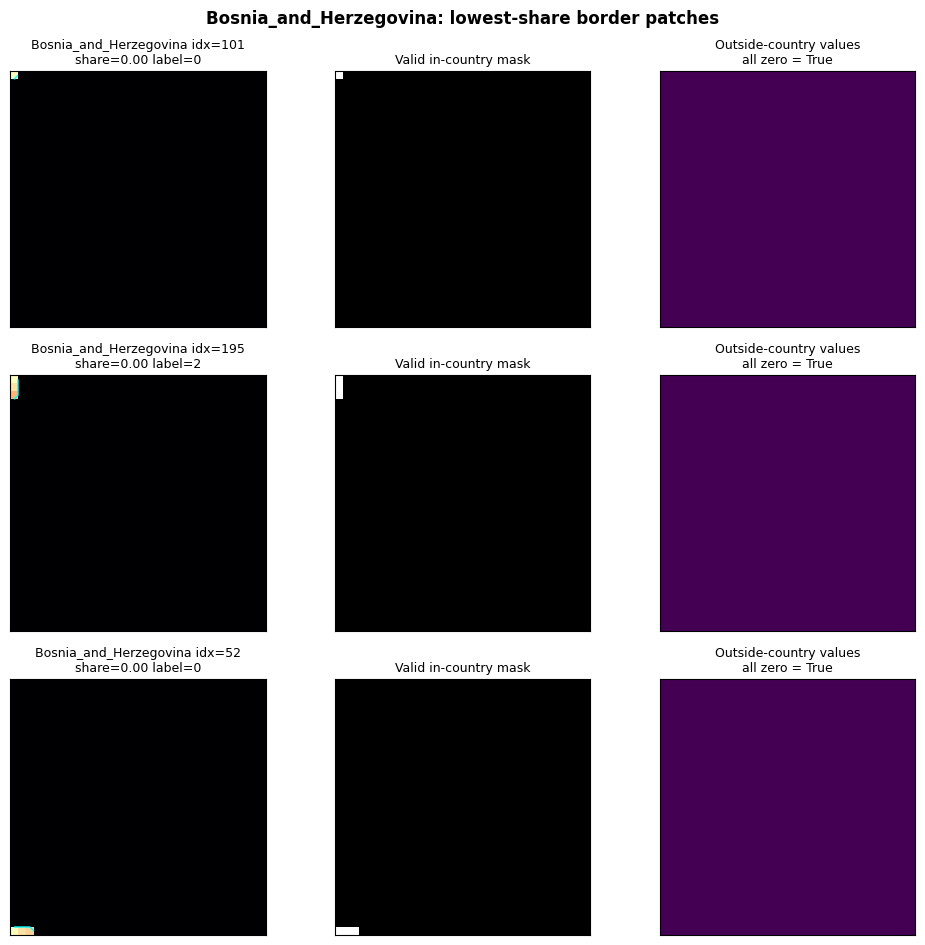

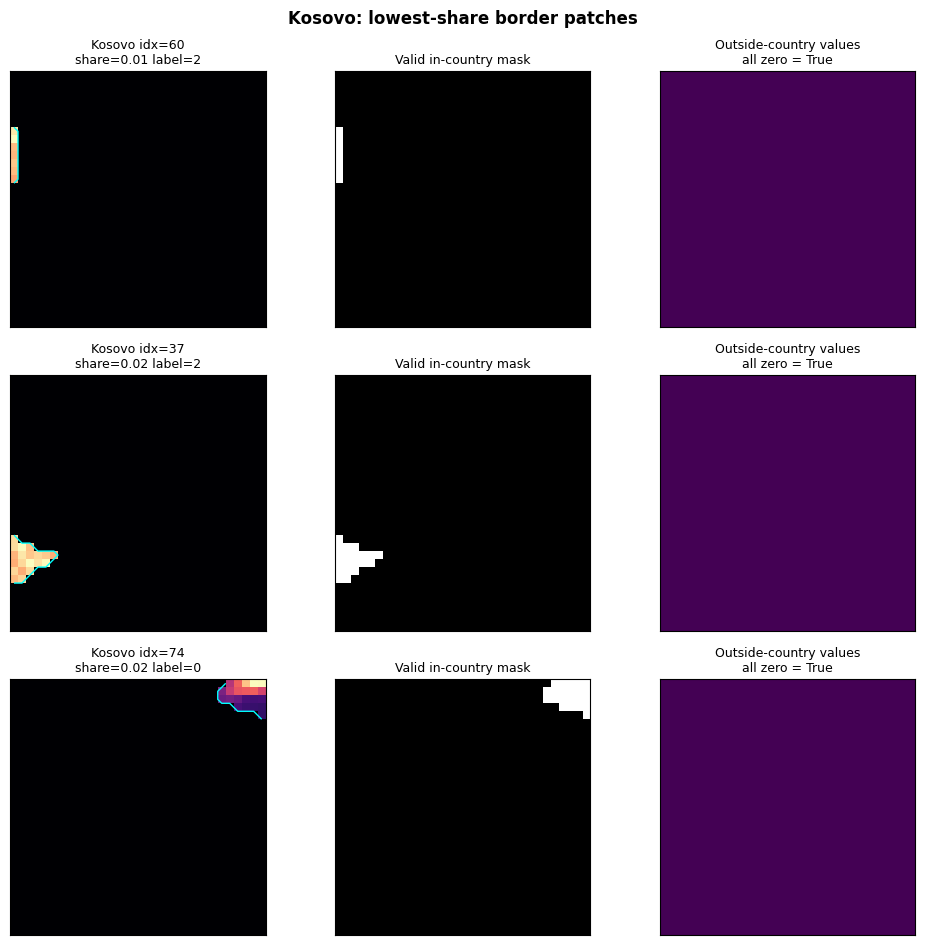

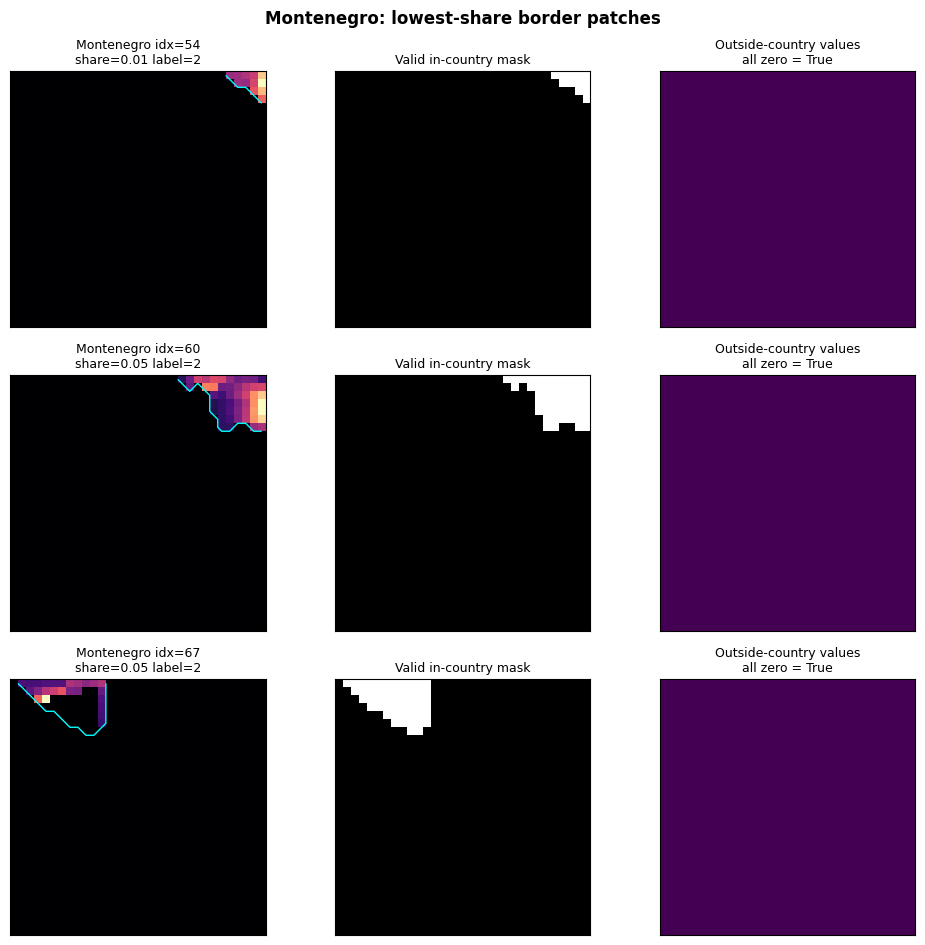

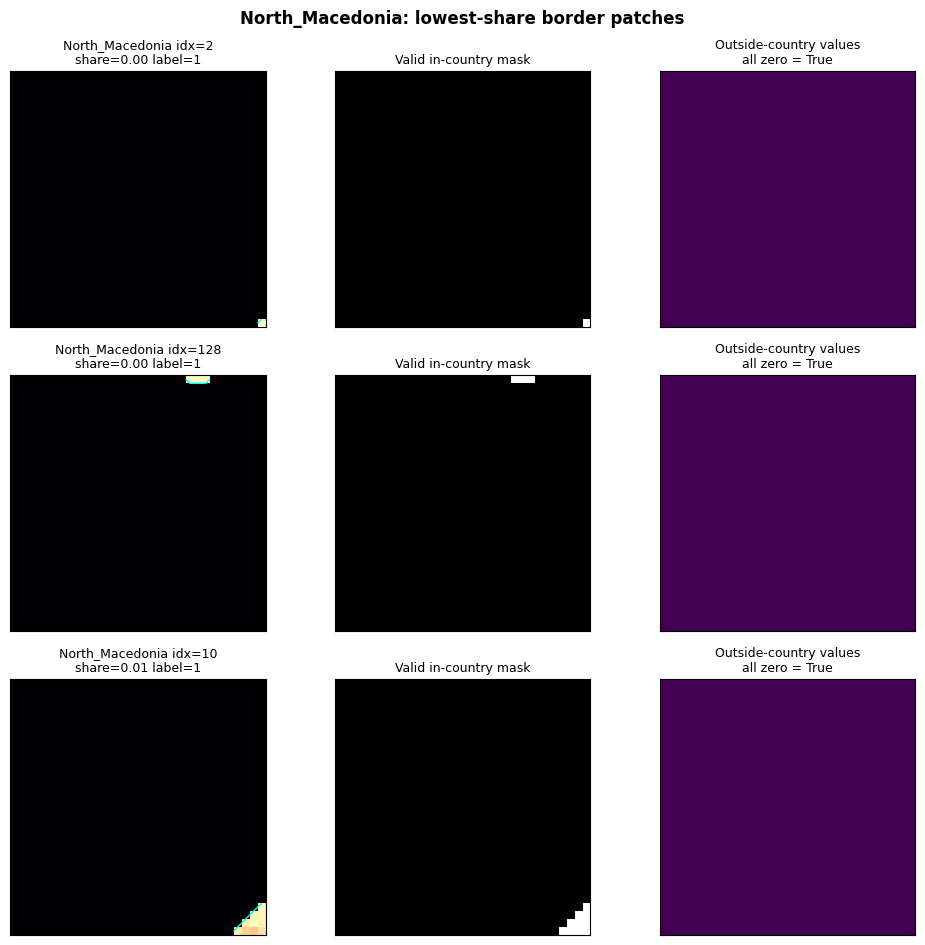

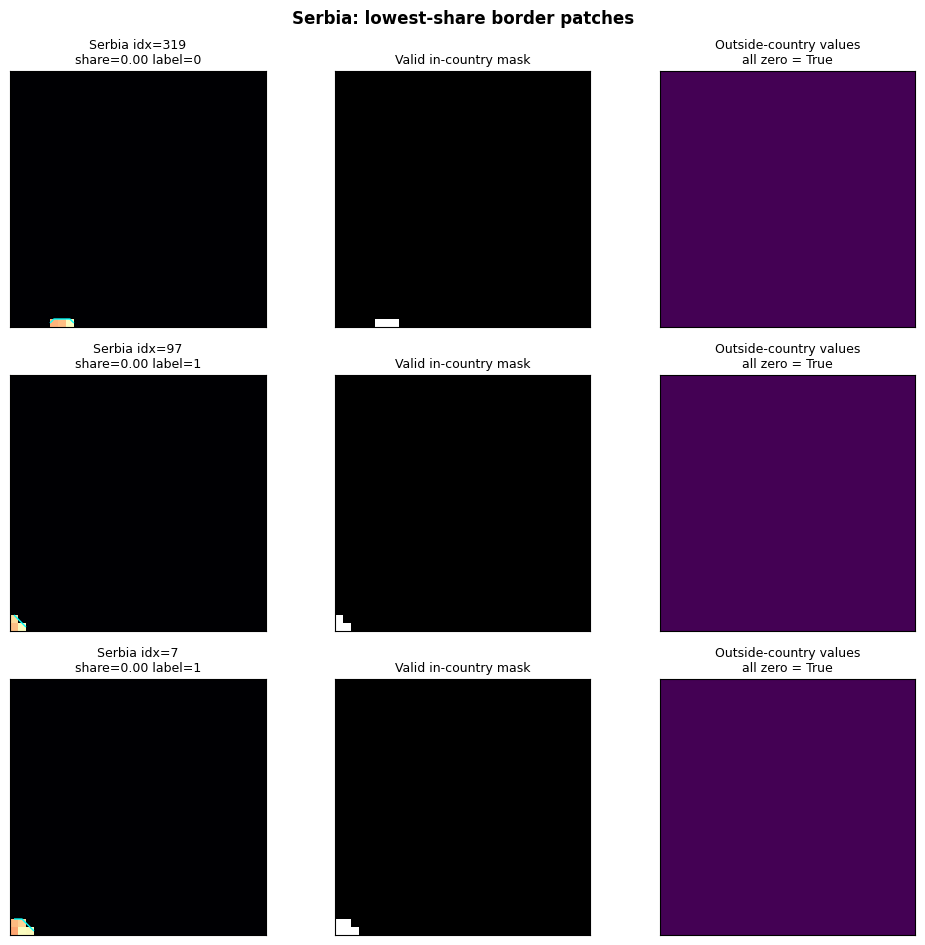

In [38]:
# Border / padding check: show the most partial patches for each country

import numpy as np
import matplotlib.pyplot as plt

top_k = 3

for country in COUNTRIES:
    patches = all_patches[country]
    masks = all_valid_masks[country]
    coords = all_patch_coords[country]
    shares = all_in_country_share[country]
    labels = all_labels[country]

    order = np.argsort(shares)[:top_k]   # smallest in-country share = strongest border patches

    fig, axes = plt.subplots(top_k, 3, figsize=(10, 3.2 * top_k))
    if top_k == 1:
        axes = np.array([axes])

    for r, idx in enumerate(order):
        vi = patches[idx][0]   # VIIRS 2013 under new INPUT_CHANNELS
        mask = masks[idx]
        zero_outside = np.all(vi[~mask] == 0) if (~mask).any() else True

        axes[r, 0].imshow(vi, cmap="magma")
        axes[r, 0].contour(mask.astype(float), levels=[0.5], colors="cyan", linewidths=1)
        axes[r, 0].set_title(
            f"{country} idx={idx}\nshare={shares[idx]:.2f} label={labels[idx]}",
            fontsize=9
        )
        axes[r, 0].set_xticks([])
        axes[r, 0].set_yticks([])

        axes[r, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[r, 1].set_title("Valid in-country mask", fontsize=9)
        axes[r, 1].set_xticks([])
        axes[r, 1].set_yticks([])

        outside = np.zeros_like(vi, dtype=float)
        if (~mask).any():
            outside[~mask] = vi[~mask]
        axes[r, 2].imshow(outside, cmap="viridis")
        axes[r, 2].set_title(f"Outside-country values\nall zero = {zero_outside}", fontsize=9)
        axes[r, 2].set_xticks([])
        axes[r, 2].set_yticks([])

    fig.suptitle(f"{country}: lowest-share border patches", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

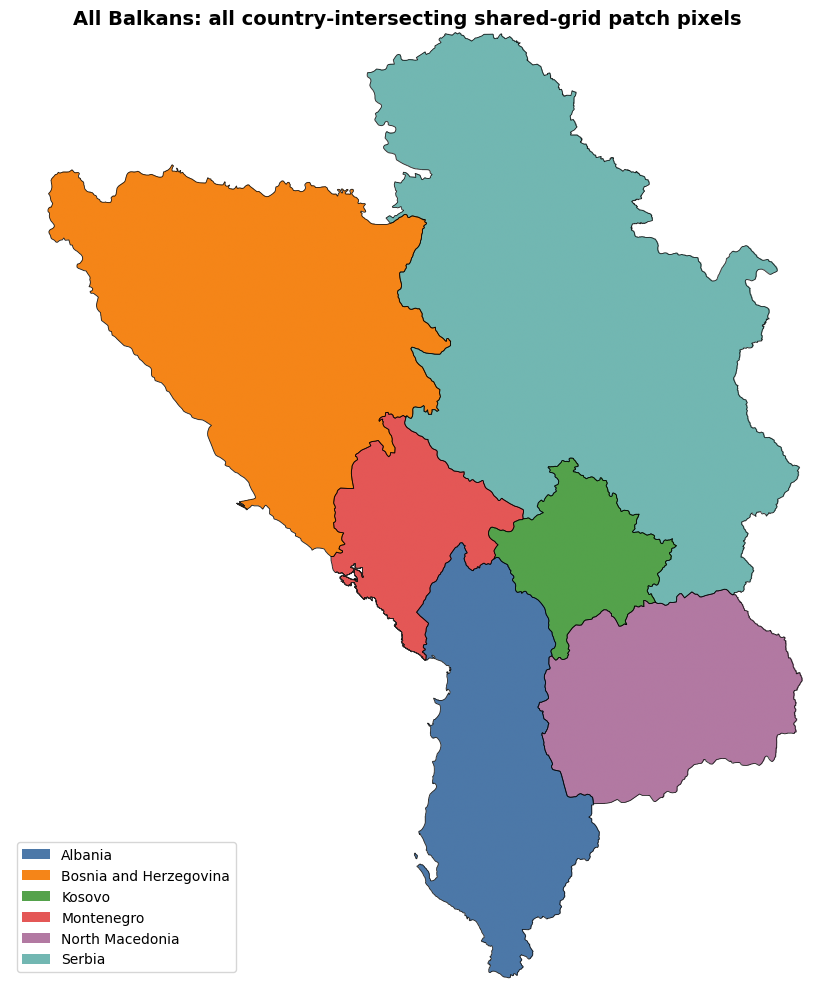

In [61]:
# Geometry-only coverage check: ignores endpoint filter
# Shows every shared 32x32 window that intersects each country.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

country_to_id = {country: i for i, country in enumerate(COUNTRIES)}
country_colors = [
    "#4C78A8",  # Albania
    "#F58518",  # Bosnia_and_Herzegovina
    "#54A24B",  # Kosovo
    "#E45756",  # Montenegro
    "#B279A2",  # North_Macedonia
    "#72B7B2",  # Serbia
]
cmap = ListedColormap(country_colors[:len(COUNTRIES)])

with rasterio.open(MEGA_TIFF_PATH) as src:
    h, w = src.height, src.width
    bounds = src.bounds
    transform = src.transform
    crs = src.crs

grid = np.full((h, w), np.nan, dtype=float)

for country in COUNTRIES:
    cid = country_to_id[country]

    gdf = load_country_boundary(country, crs)
    mask = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(h, w),
        transform=transform,
        fill=0,
        all_touched=False,
        dtype="uint8",
    ).astype(bool)

    for y in range(0, h, PATCH_SIZE):
        for x in range(0, w, PATCH_SIZE):
            h0 = min(PATCH_SIZE, h - y)
            w0 = min(PATCH_SIZE, w - x)
            patch_mask = mask[y:y+h0, x:x+w0]
            if patch_mask.any():
                block = grid[y:y+h0, x:x+w0]
                block[patch_mask] = cid
                grid[y:y+h0, x:x+w0] = block

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(
    grid,
    cmap=cmap,
    vmin=-0.5,
    vmax=len(COUNTRIES) - 0.5,
    origin="upper",
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

for country in COUNTRIES:
    gdf = load_country_boundary(country, crs).to_crs(epsg=4326)
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.6, alpha=0.8)

legend_handles = [
    Patch(facecolor=country_colors[i], label=country.replace("_", " "))
    for i, country in enumerate(COUNTRIES)
]
ax.legend(handles=legend_handles, loc="lower left", frameon=True)
ax.set_title("All Balkans: all country-intersecting shared-grid patch pixels", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Dataset and DataLoaders

In [62]:
def augment_patch(patch):
    if np.random.random() > 0.5:
        patch = np.flip(patch, axis=2).copy()
    if np.random.random() > 0.5:
        patch = np.flip(patch, axis=1).copy()
    k = np.random.randint(0, 4)
    if k > 0:
        patch = np.rot90(patch, k=k, axes=(1, 2)).copy()
    return patch


class PatchDataset(Dataset):
    def __init__(self, patches, labels, mean, std, augment=False):
        self.patches = patches
        self.labels  = labels
        self.augment = augment
        self.mean    = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std     = torch.tensor(std,  dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = self.patches[idx].copy()
        if self.augment:
            patch = augment_patch(patch)
        x = (torch.tensor(patch, dtype=torch.float32) - self.mean) / (self.std + 1e-8)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def make_loaders(test_country, batch_size=32, val_frac=0.2, seed=42):
    train_countries = [c for c in COUNTRIES if c != test_country]

    tr_patches = np.concatenate([all_patches[c] for c in train_countries])
    tr_labels  = np.concatenate([all_labels[c]  for c in train_countries])

    # normalisation computed on training countries only — no leakage
    mean = tr_patches.mean(axis=(0, 2, 3))
    std  = tr_patches.std(axis=(0, 2, 3))

    tr_p, val_p, tr_l, val_l = train_test_split(
        tr_patches, tr_labels, test_size=val_frac, random_state=seed, stratify=tr_labels
    )

    train_loader = DataLoader(
        PatchDataset(tr_p,  tr_l,  mean, std, augment=True),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        PatchDataset(val_p, val_l, mean, std, augment=False),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        PatchDataset(all_patches[test_country], all_labels[test_country], mean, std, augment=False),
        batch_size=batch_size, shuffle=False
    )
    return train_loader, val_loader, test_loader


# sanity check
tr, val, te = make_loaders("Kosovo")
print(f"Train batches: {len(tr)} | Val batches: {len(val)} | Test batches: {len(te)}")


Train batches: 127 | Val batches: 32 | Test batches: 10


## CNN architecture

In [63]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.1),
        )

    def forward(self, x):
        return self.block(x)


class NightlightCNN(nn.Module):
    """
    4-block CNN for patch_size >= 32: 32->16->8->4->2, AdaptiveAvgPool->Linear.
    Matches Jean et al. (2016) spirit: learn spatial features from multi-channel
    satellite composites to predict economic outcomes.
    """
    def __init__(self, in_channels=10, n_classes=3, patch_size=32):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)


# sanity check
dummy = torch.zeros(4, len(INPUT_CHANNELS), PATCH_SIZE, PATCH_SIZE)
model_test = NightlightCNN(in_channels=len(INPUT_CHANNELS), patch_size=PATCH_SIZE)
print(f"PATCH_SIZE={PATCH_SIZE} → output shape: {model_test(dummy).shape}")
n_params = sum(p.numel() for p in model_test.parameters())
print(f"Parameters: {n_params:,}")


PATCH_SIZE=32 → output shape: torch.Size([4, 3])
Parameters: 390,819


## Training function

In [64]:
def train_fold(test_country, epochs=80, lr=1e-3, patience=15):
    train_loader, val_loader, test_loader = make_loaders(test_country)

    model     = NightlightCNN(in_channels=len(INPUT_CHANNELS), n_classes=N_CLASSES,
                             patch_size=PATCH_SIZE).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss    = float("inf")
    patience_counter = 0
    best_state       = None
    history          = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                val_loss += criterion(model(X), y).item() * len(y)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stop at epoch {epoch + 1}")
                break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for X, y in test_loader:
            logits = model(X.to(DEVICE))
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_preds.append(logits.argmax(dim=1).cpu().numpy())
            all_true.append(y.numpy())

    y_true  = np.concatenate(all_true)
    y_pred  = np.concatenate(all_preds)
    y_probs = np.concatenate(all_probs)

    return {
        "country":  test_country,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1":       f1_score(y_true, y_pred, average="weighted"),
        "auc":      roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro"),
        "cm":       confusion_matrix(y_true, y_pred),
        "history":  history,
        "n_test":   len(y_true),
        "y_true":   y_true,
        "y_pred":   y_pred,
        "y_probs":  y_probs,
    }


## LOOCV loop

In [66]:
import pickle

results_path = PROJECT_ROOT / f"data/loocv_results_v5_{PATCH_SIZE}x{PATCH_SIZE}_{TARGET}_mega_2013static.pkl"
results_path.parent.mkdir(parents=True, exist_ok=True)

if results_path.exists():
    with open(results_path, "rb") as f:
        results = pickle.load(f)
    print(f"Loaded saved results from {results_path}.")
else:
    print(f"No saved results found at {results_path}. Running LOOCV and saving a new file.")
    torch.manual_seed(42)
    np.random.seed(42)
    results = []
    for country in COUNTRIES:
        print(f"\n--- Fold: test on {country} ---")
        r = train_fold(country)
        results.append(r)
        print(f"  Accuracy: {r['accuracy']:.3f}  F1: {r['f1']:.3f}  AUC: {r['auc']:.3f}  (n={r['n_test']})")
    with open(results_path, "wb") as f:
        pickle.dump(results, f)
    print(f"Saved results to {results_path}.")


No saved results found at data/loocv_results_v5_32x32_logratio_mega_2013static.pkl. Running LOOCV and saving a new file.

--- Fold: test on Albania ---
  Accuracy: 0.378  F1: 0.366  AUC: 0.551  (n=740)

--- Fold: test on Bosnia_and_Herzegovina ---
  Accuracy: 0.451  F1: 0.440  AUC: 0.631  (n=1314)

--- Fold: test on Kosovo ---
  Accuracy: 0.392  F1: 0.356  AUC: 0.598  (n=311)

--- Fold: test on Montenegro ---
  Accuracy: 0.383  F1: 0.312  AUC: 0.563  (n=379)

--- Fold: test on North_Macedonia ---
  Accuracy: 0.433  F1: 0.427  AUC: 0.594  (n=615)

--- Fold: test on Serbia ---
  Accuracy: 0.379  F1: 0.367  AUC: 0.557  (n=1994)
Saved results to data/loocv_results_v5_32x32_logratio_mega_2013static.pkl.


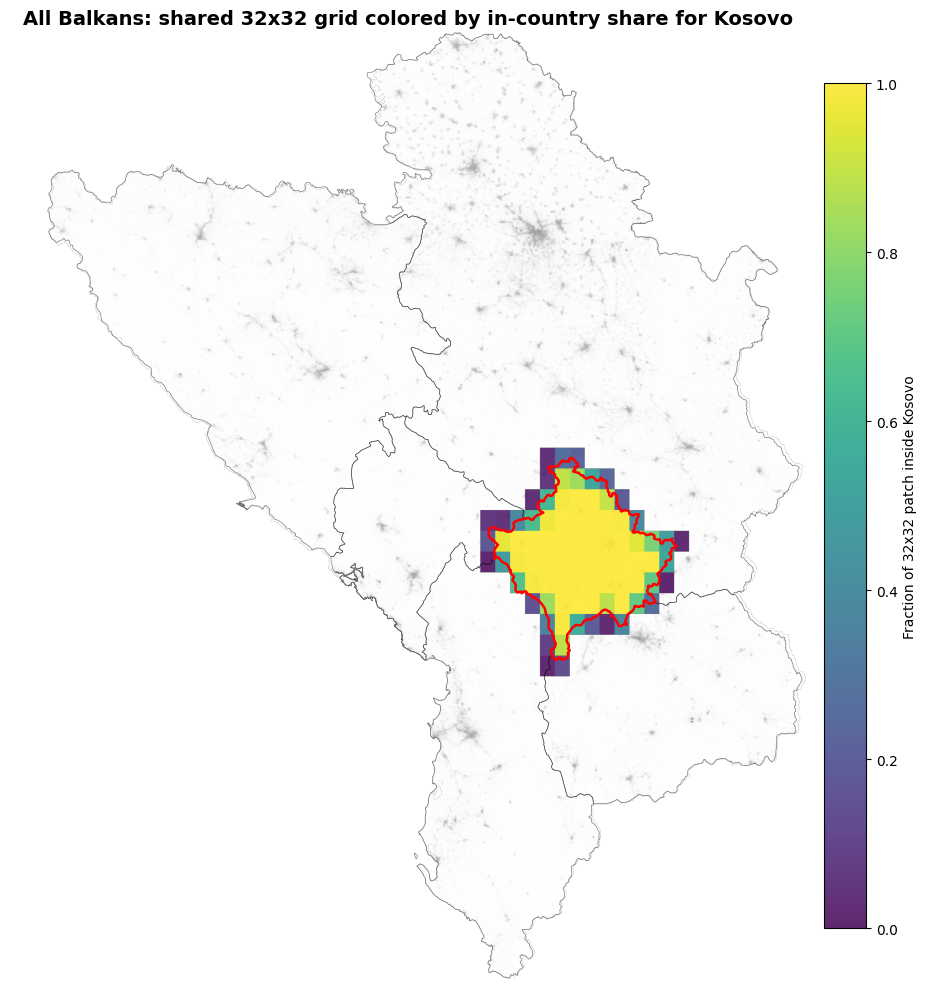

In [67]:
# Diagnostic map: every shared 32x32 window, colored by the fraction of the patch inside Kosovo
# This ignores the endpoint filter and just shows the geometry / masking share.

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.features import rasterize

TARGET_COUNTRY = "Kosovo"

with rasterio.open(MEGA_TIFF_PATH) as src:
    h, w = src.height, src.width
    bounds = src.bounds
    transform = src.transform
    crs = src.crs
    bg = np.log1p(np.clip(src.read(1), 0, None))

# Read Kosovo boundary explicitly at admin-0 level
kosovo_gdf = gpd.read_file(
    BOUNDARY_DIR / f"gadm41_{COUNTRY_GADM_CODES[TARGET_COUNTRY]}.gpkg",
    layer="ADM_ADM_0"
).to_crs(crs)

# Rasterize Kosovo mask onto the mega TIFF grid
kosovo_mask = rasterize(
    [(geom, 1) for geom in kosovo_gdf.geometry],
    out_shape=(h, w),
    transform=transform,
    fill=0,
    all_touched=False,
    dtype="uint8",
).astype(bool)

# Build a patch-share surface:
# each shared 32x32 patch gets one value = fraction of that patch inside Kosovo
share_grid = np.full((h, w), np.nan, dtype=float)

for y in range(0, h, PATCH_SIZE):
    for x in range(0, w, PATCH_SIZE):
        h0 = min(PATCH_SIZE, h - y)
        w0 = min(PATCH_SIZE, w - x)

        patch_mask = kosovo_mask[y:y+h0, x:x+w0]
        share = patch_mask.mean()

        if share > 0:
            share_grid[y:y+h0, x:x+w0] = share

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    bg,
    cmap="Greys",
    origin="upper",
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    alpha=0.55,
)

im = ax.imshow(
    share_grid,
    cmap="viridis",
    vmin=0,
    vmax=1,
    origin="upper",
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    alpha=0.85,
)

# Kosovo boundary
kosovo_gdf.to_crs(epsg=4326).boundary.plot(ax=ax, color="red", linewidth=1.8, zorder=5)

# Optional: all country borders for context
for country in COUNTRIES:
    gdf = gpd.read_file(
        BOUNDARY_DIR / f"gadm41_{COUNTRY_GADM_CODES[country]}.gpkg",
        layer="ADM_ADM_0"
    ).to_crs(epsg=4326)
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.5, zorder=4)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Fraction of 32x32 patch inside Kosovo")

ax.set_title(
    "All Balkans: shared 32x32 grid colored by in-country share for Kosovo",
    fontsize=14,
    fontweight="bold"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Results summary

In [68]:
rows = [{
    "Country":   r["country"].replace("_", " "),
    "N test":    r["n_test"],
    "Accuracy":  round(r["accuracy"], 3),
    "F1 (wtd)":  round(r["f1"],       3),
    "AUC (ovr)": round(r["auc"],      3),
} for r in results]

df = pd.DataFrame(rows)
mean_row = {
    "Country":   "Mean",
    "N test":    "—",
    "Accuracy":  round(df["Accuracy"].mean(),  3),
    "F1 (wtd)":  round(df["F1 (wtd)"].mean(),  3),
    "AUC (ovr)": round(df["AUC (ovr)"].mean(), 3),
}
df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
print(df.to_string(index=False))


               Country N test  Accuracy  F1 (wtd)  AUC (ovr)
               Albania    740     0.378     0.366      0.551
Bosnia and Herzegovina   1314     0.451     0.440      0.631
                Kosovo    311     0.392     0.356      0.598
            Montenegro    379     0.383     0.312      0.563
       North Macedonia    615     0.433     0.427      0.594
                Serbia   1994     0.379     0.367      0.557
                  Mean      —     0.403     0.378      0.582


## Confusion matrices

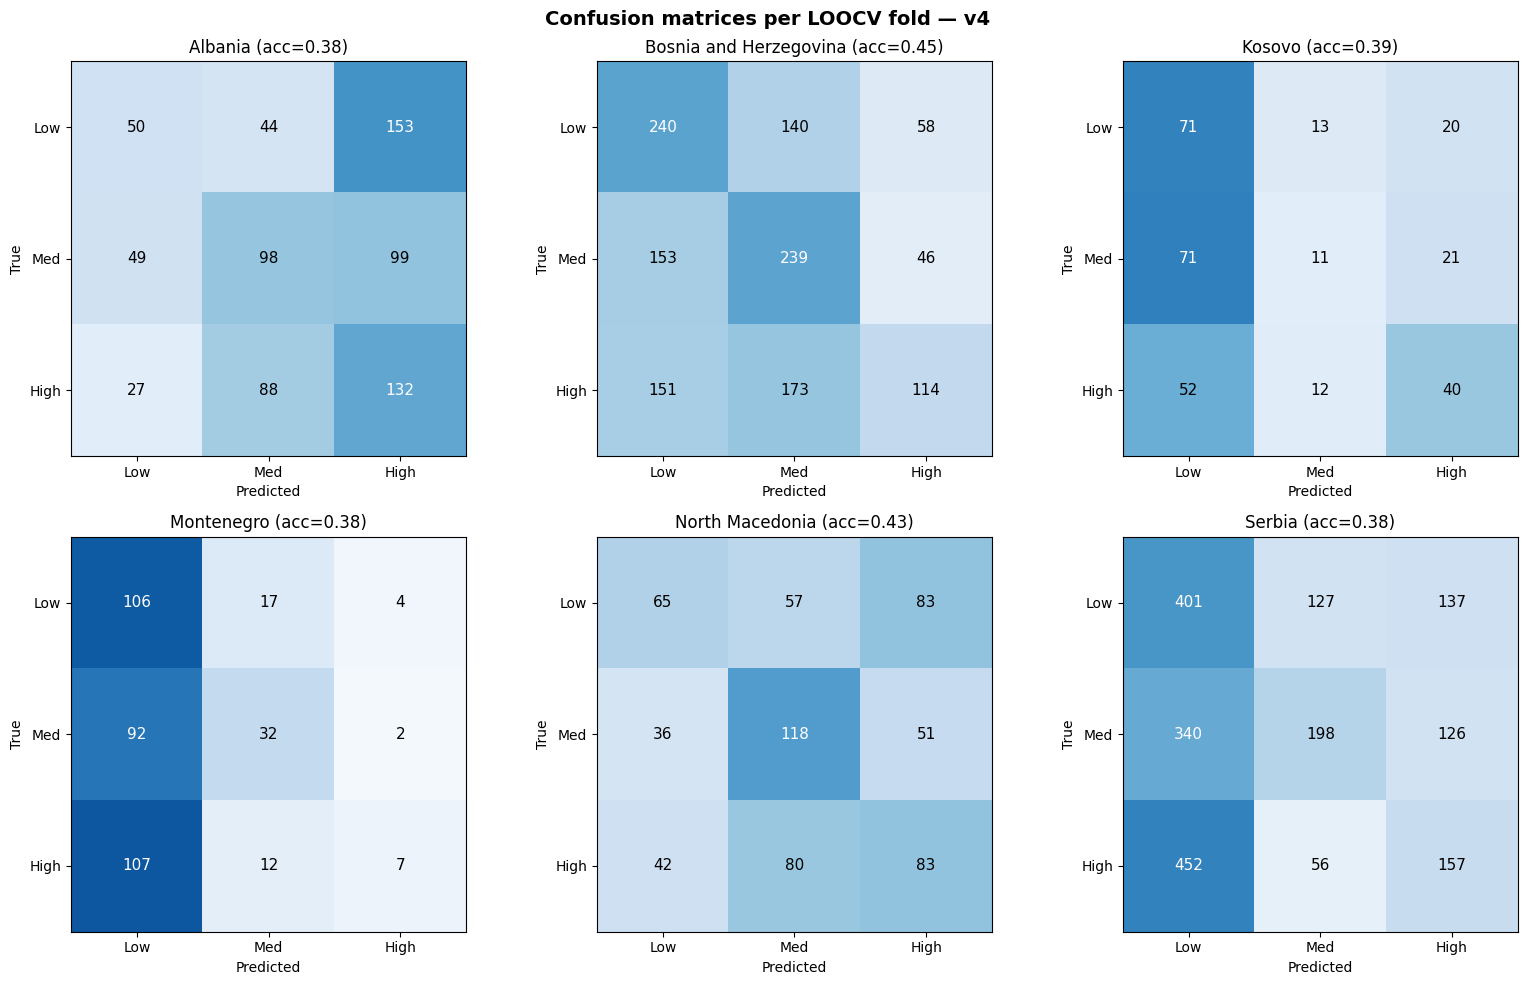

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Confusion matrices per LOOCV fold — v4", fontsize=14, fontweight="bold")
class_names = ["Low", "Med", "High"]

for ax, r in zip(axes.flat, results):
    cm      = r["cm"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(3)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{r['country'].replace('_', ' ')} (acc={r['accuracy']:.2f})")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=11)

plt.tight_layout()
plt.show()


## Loss curves

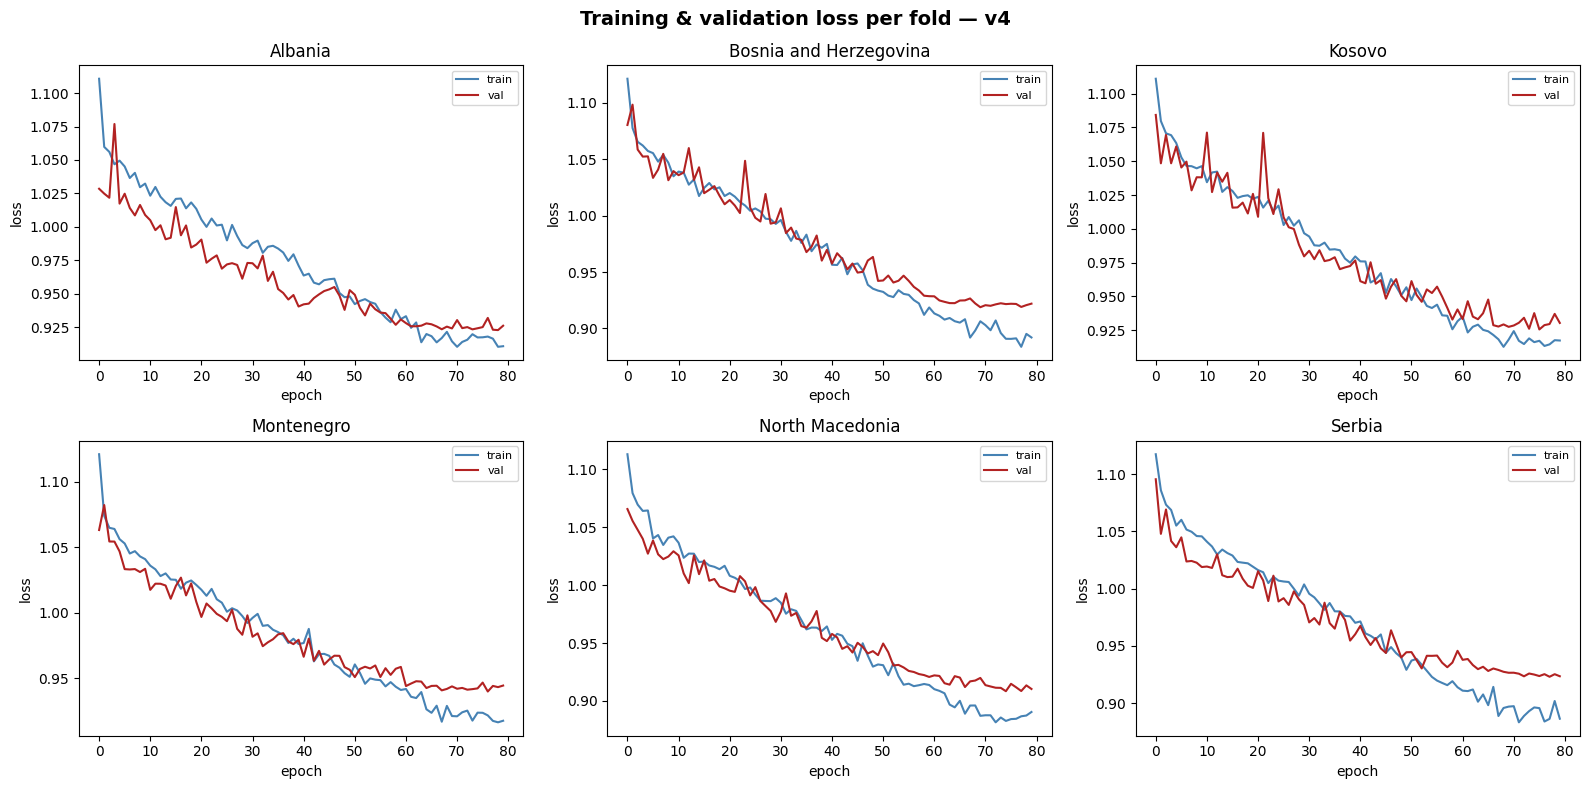

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Training & validation loss per fold — v4", fontsize=14, fontweight="bold")

for ax, r in zip(axes.flat, results):
    ax.plot(r["history"]["train_loss"], label="train", color="steelblue")
    ax.plot(r["history"]["val_loss"],   label="val",   color="firebrick")
    ax.set_title(r["country"].replace("_", " "))
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Logistic regression baseline

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

baseline_results = []
for country in COUNTRIES:
    train_countries = [c for c in COUNTRIES if c != country]
    tr_p = np.concatenate([all_patches[c] for c in train_countries])
    tr_l = np.concatenate([all_labels[c]  for c in train_countries])
    te_p = all_patches[country]
    te_l = all_labels[country]

    X_train = tr_p.mean(axis=(2, 3))  # patch-mean features
    X_test  = te_p.mean(axis=(2, 3))
    scaler  = StandardScaler().fit(X_train)
    clf     = LogisticRegression(max_iter=1000, random_state=42).fit(
        scaler.transform(X_train), tr_l
    )
    y_pred  = clf.predict(scaler.transform(X_test))
    y_probs = clf.predict_proba(scaler.transform(X_test))
    baseline_results.append({
        "Country":     country.replace("_", " "),
        "LR Accuracy": round(accuracy_score(te_l, y_pred), 3),
        "LR AUC":      round(roc_auc_score(te_l, y_probs, multi_class="ovr", average="macro"), 3),
    })

lr_df  = pd.DataFrame(baseline_results)
cnn_df = pd.DataFrame([{
    "Country":      r["country"].replace("_", " "),
    "CNN Accuracy": round(r["accuracy"], 3),
    "CNN AUC":      round(r["auc"], 3),
} for r in results])

cmp = cnn_df.merge(lr_df, on="Country")
cmp["Acc gain"] = (cmp["CNN Accuracy"] - cmp["LR Accuracy"]).round(3)
cmp["AUC gain"] = (cmp["CNN AUC"]      - cmp["LR AUC"]).round(3)

mean_row = {
    "Country":      "Mean",
    "CNN Accuracy": cmp["CNN Accuracy"].mean().round(3),
    "CNN AUC":      cmp["CNN AUC"].mean().round(3),
    "LR Accuracy":  cmp["LR Accuracy"].mean().round(3),
    "LR AUC":       cmp["LR AUC"].mean().round(3),
    "Acc gain":     cmp["Acc gain"].mean().round(3),
    "AUC gain":     cmp["AUC gain"].mean().round(3),
}
cmp = pd.concat([cmp, pd.DataFrame([mean_row])], ignore_index=True)
print(cmp.to_string(index=False))


               Country  CNN Accuracy  CNN AUC  LR Accuracy  LR AUC  Acc gain  AUC gain
               Albania         0.378    0.551        0.347   0.537     0.031     0.014
Bosnia and Herzegovina         0.451    0.631        0.435   0.628     0.016     0.003
                Kosovo         0.392    0.598        0.421   0.602    -0.029    -0.004
            Montenegro         0.383    0.563        0.364   0.578     0.019    -0.015
       North Macedonia         0.433    0.594        0.421   0.606     0.012    -0.012
                Serbia         0.379    0.557        0.388   0.594    -0.009    -0.037
                  Mean         0.403    0.582        0.396   0.591     0.007    -0.008


## CNN vs LR bar chart

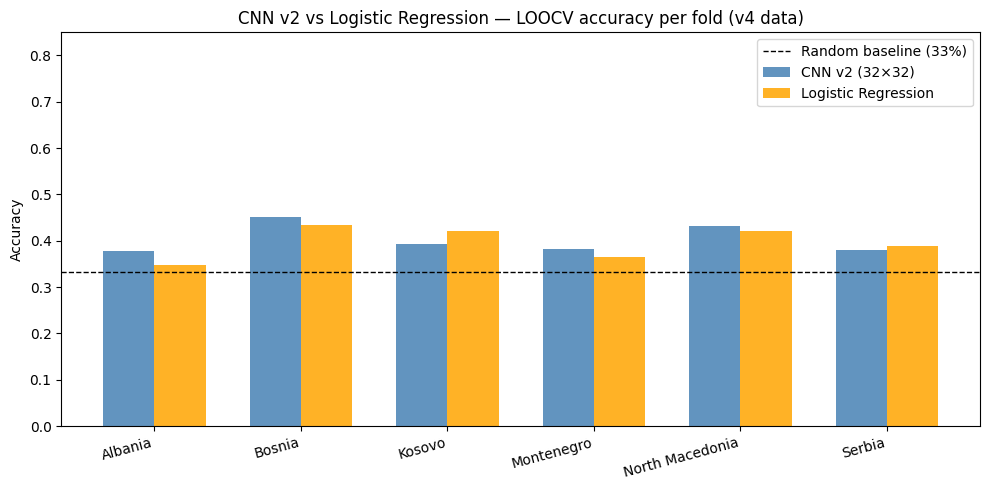

In [72]:
countries_short = [
    r["country"].replace("_", " ").replace("Bosnia and Herzegovina", "Bosnia")
    for r in results
]
cnn_accs = [r["accuracy"] for r in results]
lr_accs  = [
    float(cmp[cmp["Country"] == r["country"].replace("_", " ")]["LR Accuracy"].values[0])
    for r in results
]

x     = np.arange(len(countries_short))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, cnn_accs, width, label="CNN v2 (32×32)",     color="steelblue", alpha=0.85)
ax.bar(x + width/2, lr_accs,  width, label="Logistic Regression", color="orange",    alpha=0.85)
ax.axhline(1/3, color="black", linestyle="--", linewidth=1, label="Random baseline (33%)")
ax.set_xticks(x)
ax.set_xticklabels(countries_short, rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("CNN v2 vs Logistic Regression — LOOCV accuracy per fold (v4 data)")
ax.set_ylim(0, 0.85)
ax.legend()
plt.tight_layout()
plt.show()


## Confidence distribution

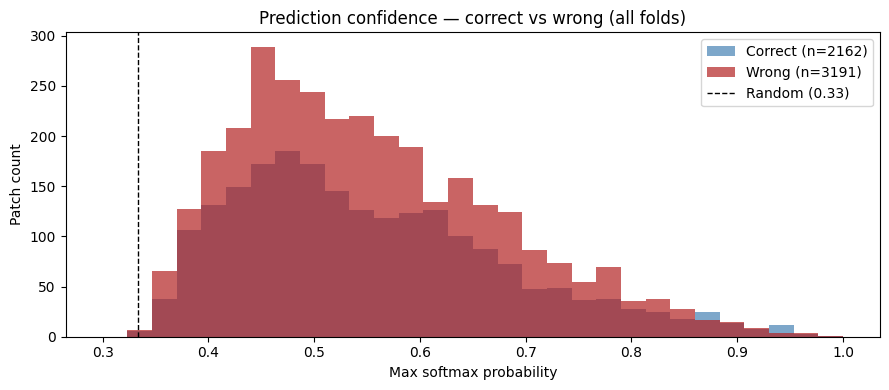

Mean confidence — correct: 0.555 | wrong: 0.553


In [73]:
all_conf_correct = []
all_conf_wrong   = []

for r in results:
    conf = r["y_probs"].max(axis=1)
    all_conf_correct.extend(conf[r["y_true"] == r["y_pred"]].tolist())
    all_conf_wrong.extend(conf[r["y_true"] != r["y_pred"]].tolist())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_conf_correct, bins=30, range=(0.3, 1.0), alpha=0.7,
        color="steelblue", label=f"Correct (n={len(all_conf_correct)})")
ax.hist(all_conf_wrong,   bins=30, range=(0.3, 1.0), alpha=0.7,
        color="firebrick", label=f"Wrong (n={len(all_conf_wrong)})")
ax.axvline(1/3, color="black", linestyle="--", linewidth=1, label="Random (0.33)")
ax.set_xlabel("Max softmax probability")
ax.set_ylabel("Patch count")
ax.set_title("Prediction confidence — correct vs wrong (all folds)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean confidence — correct: {np.mean(all_conf_correct):.3f} | wrong: {np.mean(all_conf_wrong):.3f}")


## All-Balkans out-of-country prediction maps

These figures stitch together the LOOCV test-fold outputs for all six countries.
Every patch is shown only in the fold where that country was held out.

Map options:
- `discrete`: modal out-of-country class after aggregating overlapping patches
- `soft_score`: expected class score `0*P(Low) + 1*P(Mid) + 2*P(High)`
- `high_prob`: out-of-country predicted probability of High relative growth
- `residual`: signed soft residual `expected class - true class`


In [74]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

CLASS_NAMES = ["Low", "Mid", "High"]
CLASS_CMAP = ListedColormap(["steelblue", "goldenrod", "firebrick"])
CLASS_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], CLASS_CMAP.N)
CONTINUOUS_SPECS = {
    "soft_score": {
        "cmap": "viridis",
        "vmin": 0.0,
        "vmax": 2.0,
        "label": "Expected class score",
        "title": "Soft score map",
    },
    "high_prob": {
        "cmap": "magma",
        "vmin": 0.0,
        "vmax": 1.0,
        "label": "P(High)",
        "title": "Out-of-country P(High)",
    },
    "residual": {
        "cmap": "RdBu_r",
        "vmin": -1.0,
        "vmax": 1.0,
        "label": "Expected class - true class",
        "title": "Signed residual map",
    },
}

result_by_country = {r["country"]: r for r in results}

with rasterio.open(MEGA_TIFF_PATH) as src:
    mega_raw = src.read().astype(np.float32)
    mega_bounds = src.bounds
    mega_shape = (src.height, src.width)
    mega_crs = src.crs

mega_bg = np.log1p(np.clip(mega_raw[0], 0, None))
bg_valid = mega_bg[np.isfinite(mega_bg)]
bg_vmin = float(np.percentile(bg_valid, 1))
bg_vmax = float(np.percentile(bg_valid, 99))
mega_extent = [mega_bounds.left, mega_bounds.right, mega_bounds.bottom, mega_bounds.top]

padded_h = int(np.ceil(mega_shape[0] / PATCH_SIZE) * PATCH_SIZE)
padded_w = int(np.ceil(mega_shape[1] / PATCH_SIZE) * PATCH_SIZE)

boundary_frames = []
for country in COUNTRIES:
    gdf = load_country_boundary(country, mega_crs).to_crs(epsg=4326)
    boundary_frames.append(gdf[["country", "geometry"]])
balkans_boundaries = gpd.GeoDataFrame(
    pd.concat(boundary_frames, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326",
)


def country_prediction_surfaces(country: str) -> dict:
    coords = all_patch_coords[country]
    valid_masks = all_valid_masks[country]
    fold = result_by_country[country]
    y_true = fold["y_true"]
    y_pred = fold["y_pred"]
    y_probs = fold["y_probs"]

    if len(coords) != len(y_pred):
        raise ValueError(
            f"{country}: coord count {len(coords)} does not match predictions {len(y_pred)}"
        )

    count = np.zeros((padded_h, padded_w), dtype=np.float32)
    class_votes = np.zeros((3, padded_h, padded_w), dtype=np.float32)
    soft_sum = np.zeros((padded_h, padded_w), dtype=np.float32)
    high_sum = np.zeros((padded_h, padded_w), dtype=np.float32)
    residual_sum = np.zeros((padded_h, padded_w), dtype=np.float32)

    class_values = np.array([0.0, 1.0, 2.0], dtype=np.float32)

    for (y, x), valid_mask, true_cls, pred_cls, probs in zip(coords, valid_masks, y_true, y_pred, y_probs):
        ys = slice(int(y), int(y) + PATCH_SIZE)
        xs = slice(int(x), int(x) + PATCH_SIZE)
        score = float(np.dot(probs, class_values))

        count_patch = count[ys, xs]
        count_patch[valid_mask] += 1.0
        count[ys, xs] = count_patch

        vote_patch = class_votes[int(pred_cls), ys, xs]
        vote_patch[valid_mask] += 1.0
        class_votes[int(pred_cls), ys, xs] = vote_patch

        soft_patch = soft_sum[ys, xs]
        soft_patch[valid_mask] += score
        soft_sum[ys, xs] = soft_patch

        high_patch = high_sum[ys, xs]
        high_patch[valid_mask] += float(probs[2])
        high_sum[ys, xs] = high_patch

        residual_patch = residual_sum[ys, xs]
        residual_patch[valid_mask] += score - float(true_cls)
        residual_sum[ys, xs] = residual_patch

    count = count[: mega_shape[0], : mega_shape[1]]
    class_votes = class_votes[:, : mega_shape[0], : mega_shape[1]]
    soft_sum = soft_sum[: mega_shape[0], : mega_shape[1]]
    high_sum = high_sum[: mega_shape[0], : mega_shape[1]]
    residual_sum = residual_sum[: mega_shape[0], : mega_shape[1]]

    observed = count > 0
    discrete = np.full(mega_shape, np.nan, dtype=np.float32)
    soft_score = np.full(mega_shape, np.nan, dtype=np.float32)
    high_prob = np.full(mega_shape, np.nan, dtype=np.float32)
    residual = np.full(mega_shape, np.nan, dtype=np.float32)

    discrete_votes = np.argmax(class_votes, axis=0).astype(np.float32)
    discrete[observed] = discrete_votes[observed]
    soft_score[observed] = soft_sum[observed] / count[observed]
    high_prob[observed] = high_sum[observed] / count[observed]
    residual[observed] = residual_sum[observed] / count[observed]

    return {
        "discrete": discrete,
        "soft_score": soft_score,
        "high_prob": high_prob,
        "residual": residual,
    }


balkans_maps = {country: country_prediction_surfaces(country) for country in COUNTRIES}


def plot_balkans_surface(mode: str, ax=None, alpha: float = 0.68, border_color: str = "white"):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 8))

    ax.imshow(
        mega_bg,
        cmap="Greys",
        vmin=bg_vmin,
        vmax=bg_vmax,
        extent=mega_extent,
        origin="upper",
    )

    image = None
    for country in COUNTRIES:
        surface = balkans_maps[country][mode]
        if mode == "discrete":
            image = ax.imshow(
                surface,
                cmap=CLASS_CMAP,
                norm=CLASS_NORM,
                alpha=alpha,
                extent=mega_extent,
                origin="upper",
            )
        else:
            spec = CONTINUOUS_SPECS[mode]
            image = ax.imshow(
                surface,
                cmap=spec["cmap"],
                vmin=spec["vmin"],
                vmax=spec["vmax"],
                alpha=alpha,
                extent=mega_extent,
                origin="upper",
            )

    balkans_boundaries.boundary.plot(ax=ax, color="black", linewidth=0.9, alpha=0.8, zorder=5)
    balkans_boundaries.boundary.plot(ax=ax, color=border_color, linewidth=0.5, alpha=0.9, zorder=6)

    ax.set_axis_off()
    ax.set_title(
        {
            "discrete": "Discrete class map",
            "soft_score": "Soft score map",
            "high_prob": "Out-of-country P(High)",
            "residual": "Signed residual map",
        }[mode]
    )
    return image


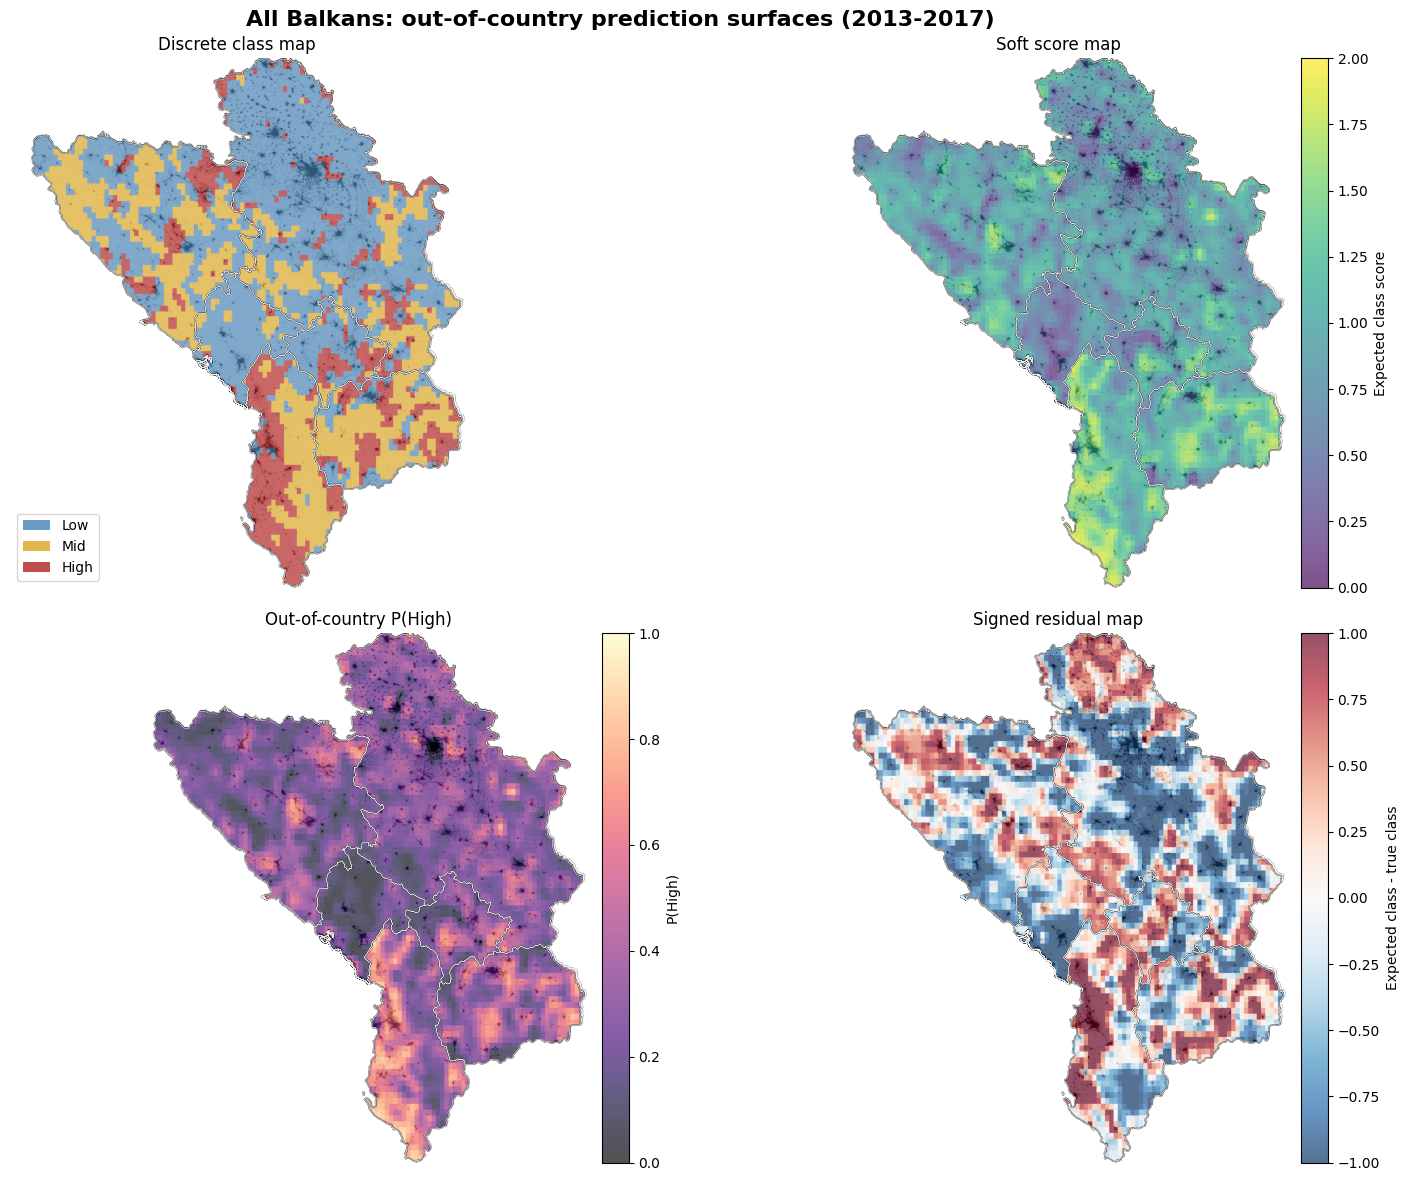

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
modes = ["discrete", "soft_score", "high_prob", "residual"]

for ax, mode in zip(axes.flat, modes):
    im = plot_balkans_surface(mode, ax=ax)
    if mode == "discrete":
        legend_handles = [
            Patch(facecolor=CLASS_CMAP.colors[i], label=CLASS_NAMES[i], alpha=0.8)
            for i in range(3)
        ]
        ax.legend(handles=legend_handles, loc="lower left", frameon=True)
    else:
        spec = CONTINUOUS_SPECS[mode]
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label(spec["label"])

fig.suptitle(
    "All Balkans: out-of-country prediction surfaces (2013-2017)",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


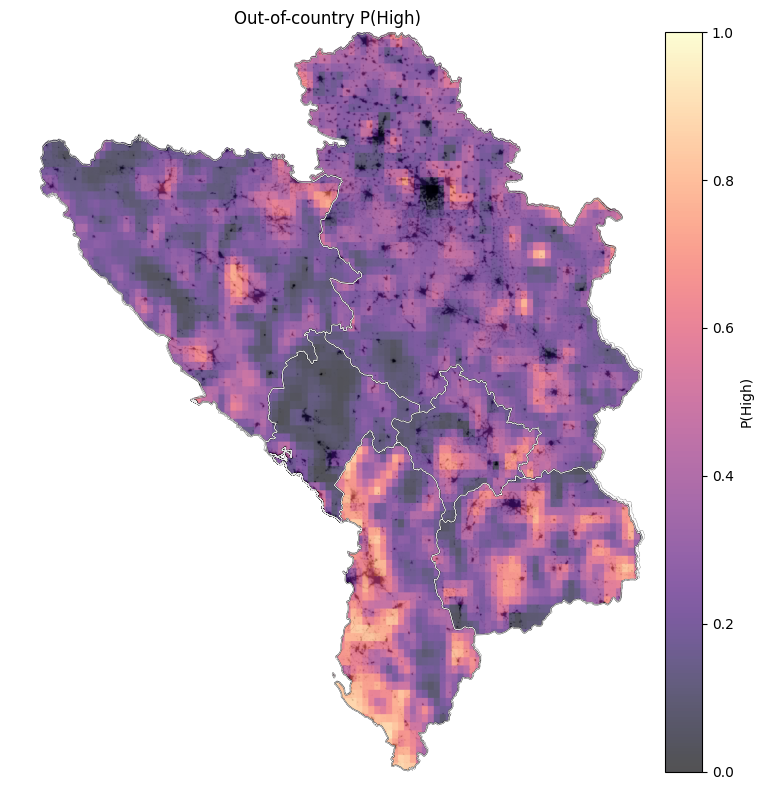

In [76]:
# Change `selected_mode` to inspect one option at larger size.
selected_mode = "high_prob"  # discrete | soft_score | high_prob | residual

fig, ax = plt.subplots(figsize=(11, 8))
im = plot_balkans_surface(selected_mode, ax=ax)

if selected_mode == "discrete":
    legend_handles = [
        Patch(facecolor=CLASS_CMAP.colors[i], label=CLASS_NAMES[i], alpha=0.8)
        for i in range(3)
    ]
    ax.legend(handles=legend_handles, loc="lower left", frameon=True)
else:
    spec = CONTINUOUS_SPECS[selected_mode]
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(spec["label"])

plt.tight_layout()
plt.show()
